# 11. Cross-asset rolling-ARI resonance figure

Renders the cross-asset rolling-ARI resonance figure (Supplementary
Material). Compares the rolling 7-day mean off-diagonal ARI across
assets to show that the cross-frequency dissonance signal moves
coherently across asset classes during the 2026 Iran episode.

The notebook re-creates the figure in-process from each asset's cached
`{ASSET}_rolling_7d_ari.csv` (produced by `python run.py pipeline`),
then displays the cached PNG for comparison.

**Re-run command**: `python run.py cross_asset`

In [1]:
from __future__ import annotations
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

PROJECT = Path.cwd()
_nb_file = globals().get("__vsc_ipynb_file__")
if _nb_file is not None:
    PROJECT = Path(_nb_file).resolve().parent.parent
elif PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
sys.path.insert(0, str(PROJECT))

OUT = PROJECT / "outputs"
OUT_2022 = PROJECT / "outputs_2022"
DATA = PROJECT / "data"
DATA_2022 = PROJECT / "data_2022"

pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 50)

## Step 1 -- load each asset's cached rolling-7d ARI

In [2]:
rolls = {}
for asset in ['SPY', 'USDJPY', 'CL', 'GLD']:
    p = OUT / f"{asset}_rolling_7d_ari.csv"
    if not p.exists():
        continue
    df = pd.read_csv(p, parse_dates=[0])
    df = df.set_index(df.columns[0])
    rolls[asset] = df["mean_offdiag_ari"]
print({k: len(v) for k, v in rolls.items()})

{'SPY': 118, 'USDJPY': 150, 'CL': 149, 'GLD': 118}


## Step 2 -- plot all-asset rolling ARI overlay (in-process)

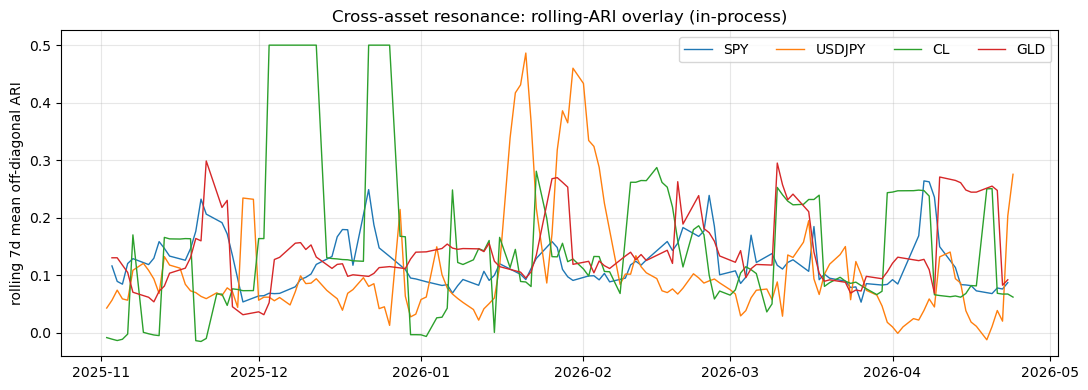

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
for asset, ser in rolls.items():
    ax.plot(ser.index, ser.values, label=asset, lw=1.0)
ax.set_ylabel("rolling 7d mean off-diagonal ARI")
ax.set_title("Cross-asset resonance: rolling-ARI overlay (in-process)")
ax.legend(ncol=len(rolls))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Cached paper figure -- `outputs/cross_asset_resonance.png`

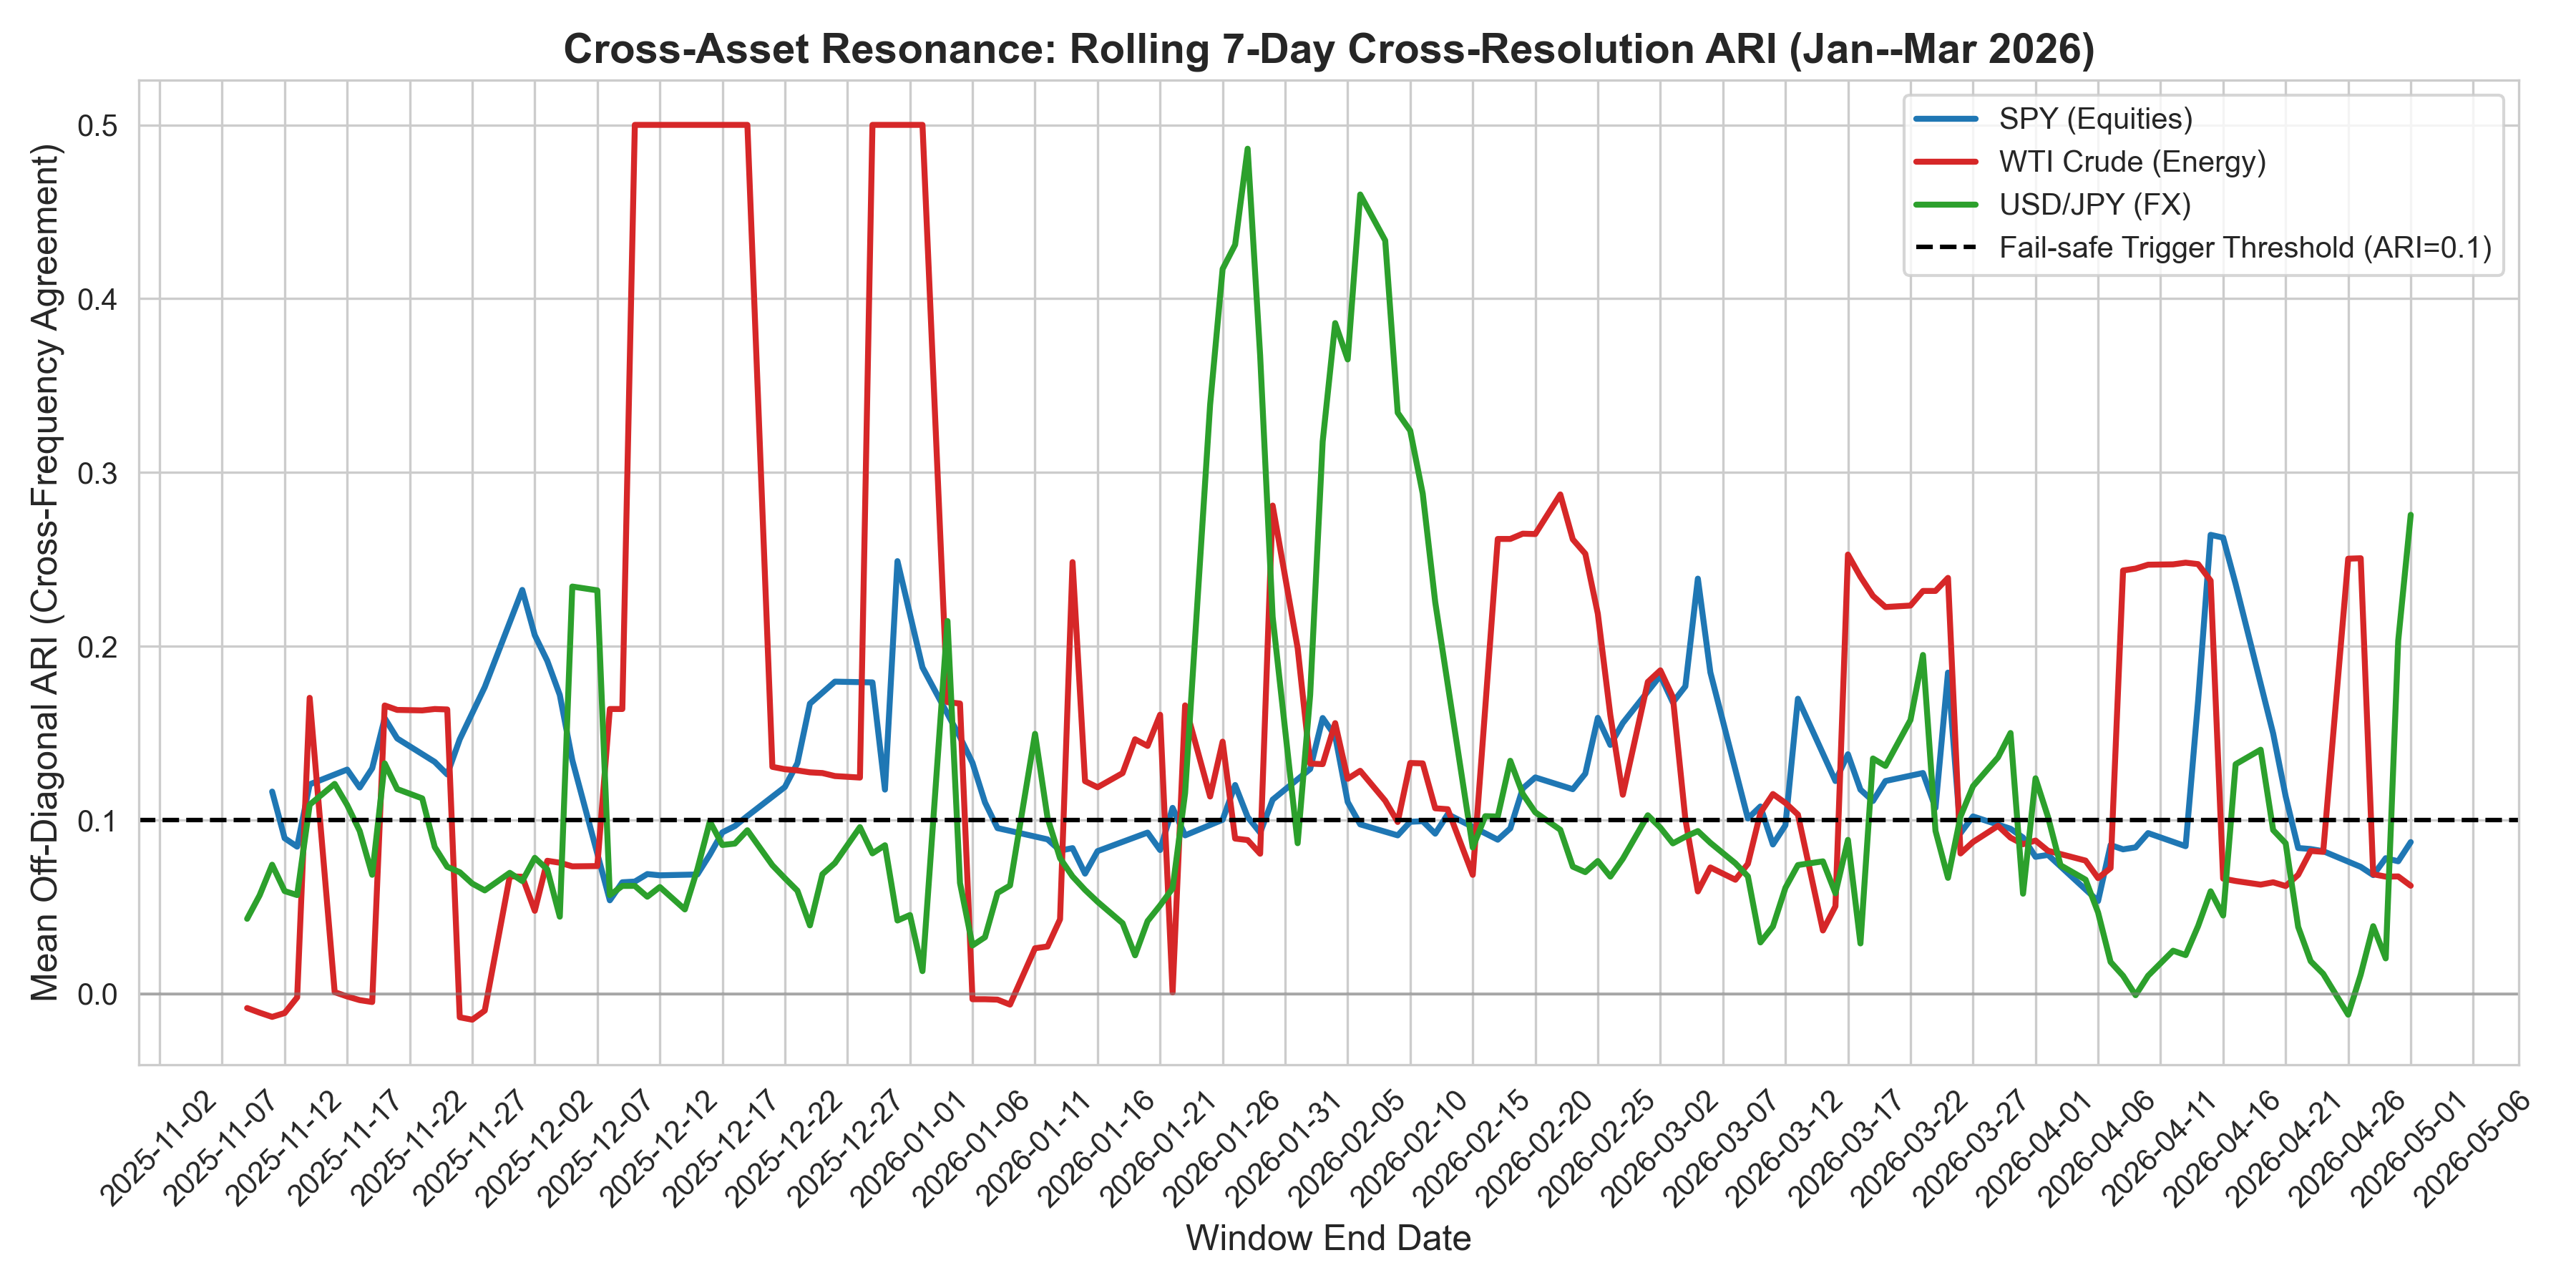

In [4]:
img = OUT / "cross_asset_resonance.png"
if img.exists():
    display(Image(filename=str(img)))
else:
    img2 = OUT / "cross_asset_resonance_rolling_ari.png"
    if img2.exists():
        display(Image(filename=str(img2)))
    else:
        display(Markdown("Figure missing -- run `python run.py cross_asset`."))